In [104]:
from tqdm import tqdm
import numpy as np
import torch
import collections
import random

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = collections.deque(maxlen=capacity) 

    def add(self, state, action, reward, next_state, done): 
        self.buffer.append((state, action, reward, next_state, done)) 

    def sample(self, batch_size): 
        transitions = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*transitions)
        return np.array(state), action, reward, np.array(next_state), done 

    def size(self): 
        return len(self.buffer)

def moving_average(a, window_size):
    cumulative_sum = np.cumsum(np.insert(a, 0, 0)) 
    middle = (cumulative_sum[window_size:] - cumulative_sum[:-window_size]) / window_size
    r = np.arange(1, window_size-1, 2)
    begin = np.cumsum(a[:window_size-1])[::2] / r
    end = (np.cumsum(a[:-window_size:-1])[::2] / r)[::-1]
    return np.concatenate((begin, middle, end))

def train_on_policy_agent(env, agent, num_episodes):
    return_list = []
    for i in range(10):
        with tqdm(total=int(num_episodes/10), desc='Iteration %d' % i) as pbar:
            for i_episode in range(int(num_episodes/10)):
                episode_return = 0
                transition_dict = {'states': [], 'actions': [], 'next_states': [], 'rewards': [], 'dones': []}
                state = env.reset()
                done = False
                while not done:
                    action = agent.take_action(state)
                    next_state, reward, done, _ = env.step(action)
                    transition_dict['states'].append(state)
                    transition_dict['actions'].append(action)
                    transition_dict['next_states'].append(next_state)
                    transition_dict['rewards'].append(reward)
                    transition_dict['dones'].append(done)
                    state = next_state
                    episode_return += reward
                return_list.append(episode_return)
                agent.update(transition_dict)
                if (i_episode+1) % 10 == 0:
                    pbar.set_postfix({'episode': '%d' % (num_episodes/10 * i + i_episode+1), 'return': '%.3f' % np.mean(return_list[-10:])})
                pbar.update(1)
    return return_list

def train_off_policy_agent(env, agent, num_episodes, replay_buffer, minimal_size, batch_size):
    return_list = []
    for i in range(10):
        with tqdm(total=int(num_episodes/10), desc='Iteration %d' % i) as pbar:
            for i_episode in range(int(num_episodes/10)):
                episode_return = 0
                state = env.reset()
                done = False
                while not done:
                    action = agent.take_action(state)
                    next_state, reward, done, _ = env.step(action)
                    replay_buffer.add(state, action, reward, next_state, done)
                    state = next_state
                    episode_return += reward
                    if replay_buffer.size() > minimal_size:
                        b_s, b_a, b_r, b_ns, b_d = replay_buffer.sample(batch_size)
                        transition_dict = {'states': b_s, 'actions': b_a, 'next_states': b_ns, 'rewards': b_r, 'dones': b_d}
                        agent.update(transition_dict)
                return_list.append(episode_return)
                if (i_episode+1) % 10 == 0:
                    pbar.set_postfix({'episode': '%d' % (num_episodes/10 * i + i_episode+1), 'return': '%.3f' % np.mean(return_list[-10:])})
                pbar.update(1)
    return return_list


def compute_advantage(gamma, lmbda, td_delta):
    td_delta = td_delta.detach().numpy()
    advantage_list = []
    advantage = 0.0
    for delta in td_delta[::-1]:
        advantage = gamma * lmbda * advantage + delta
        advantage_list.append(advantage)
    advantage_list.reverse()
    return torch.tensor(advantage_list, dtype=torch.float)
                

In [105]:
import gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [127]:
class PolicyNet(nn.Module):
    def __init__(self, state_dim, hidden_dim, action_dim):
        super(PolicyNet, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.ReLU1 = nn.LeakyReLU(inplace = True)
        self.fc2 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = self.ReLU1(self.fc1(x))
        x = self.fc2(x)
        return F.softmax(x, dim=1)

In [128]:
class ValueNet(nn.Module):
    def __init__(self, state_dim, hidden_dim):
        super(ValueNet, self).__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.ReLU1 = nn.LeakyReLU(inplace = True)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.ReLU1(self.fc1(x))
        return self.fc2(x)

In [171]:
class PPOclip:
    def __init__(self, actor, critic, actor_lr, critic_lr, epochs, epsilon, gamma, lmbda, device):
        # policy network
        self.actor = actor
        # value network
        self.critic = critic
        # policy optimizer and value optimizer
        self.actor_optimizer = torch.optim.Adam(self.actor.parameters(),lr=actor_lr)
        self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=critic_lr)
        self.epochs = epochs
        self.epsilon = epsilon
        self.gamma = gamma
        self.lmbda = lmbda
        self.device = device
 
    def take_action(self, state):
        state = torch.tensor([state], dtype=torch.float).to(self.device)
        probs = self.actor(state)
        action_dist = torch.distributions.Categorical(probs)
        action = action_dist.sample()
        return action.item()
    
    def update(self, trans_dict):
        # trans_dict is a dictionary for transistions in one episode
        # one transition (s,a,r,s',d)
        
        states = torch.tensor(trans_dict['states'], dtype=torch.float).to(self.device)
        actions = torch.tensor(trans_dict['actions']).view(-1, 1).to(self.device)
        rewards = torch.tensor(trans_dict['rewards'], dtype=torch.float).view(-1, 1).to(self.device)
        next_states = torch.tensor(trans_dict['next_states'],dtype=torch.float).to(self.device)
        dones = torch.tensor(trans_dict['dones'],dtype=torch.float).view(-1, 1).to(self.device)

        # TD target
        td_target = rewards + self.gamma * self.critic(next_states) * (1 - dones)
        td_error = td_target - self.critic(states)  # TD error
        
        # advantage
        advantage = compute_advantage(self.gamma, self.lmbda, td_error.cpu()).to(self.device)
        
        old_log_probs = torch.log(self.actor(states).gather(1, actions)).detach()
        # .detach(): no gradient calculation for old actor
        
        # train for a few epochs
        for _ in range(self.epochs):
            log_probs = torch.log(self.actor(states).gather(1, actions))
            ratio = torch.exp(log_probs - old_log_probs)
            
            #surr1 = ratio * advantage
            #surr2 = torch.clamp(ratio, 1-self.epsilon, 1+self.epsilon)*advantage
            #actor_loss = torch.mean(-torch.min(surr1, surr2))
            surr1 = ratio * advantage
            surr2 = (1+torch.sign(advantage)*self.epsilon)*advantage
            
            actor_loss = torch.mean(-torch.min(surr1, surr2))
            
            square_error = F.mse_loss(self.critic(states), td_target.detach())
            critic_loss = torch.mean(square_error)
            self.actor_optimizer.zero_grad()
            self.critic_optimizer.zero_grad()
            actor_loss.backward()  # calculate actor gradient
            critic_loss.backward()  # calculate critic gradient
            self.actor_optimizer.step()  # update actor
            self.critic_optimizer.step()  # update critic

In [180]:
actor_lr = 1e-4  # 1e-3
critic_lr = 1e-2  
num_episodes = 1000
hidden_dim = 128
gamma = 0.98
lmbda = 0.95
epochs = 10
epsilon = 0.2

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
env_name = 'CartPole-v0'
#env_name = 'MountainCar-v0'
env = gym.make(env_name)
env.seed(0)
torch.manual_seed(0)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

In [181]:
actor = PolicyNet(state_dim, hidden_dim, action_dim).to(device)
critic = ValueNet(state_dim, hidden_dim).to(device)
agent = PPOclip(actor, critic, actor_lr, critic_lr, epochs, epsilon, gamma, lmbda, device)
#return_list = train_on_policy_agent(env, agent, num_episodes)


In [182]:
return_list = train_on_policy_agent(env, agent, num_episodes)

Iteration 9: 100%|█████████████████████████████████████| 100/100 [00:11<00:00,  8.73it/s, episode=1000, return=200.000]


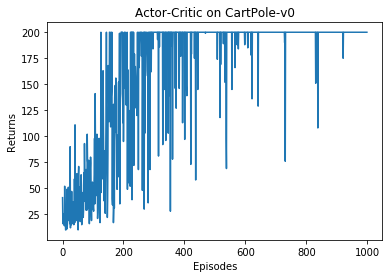

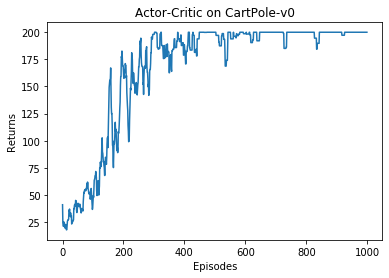

In [183]:
episodes_list = list(range(len(return_list)))
plt.plot(episodes_list, return_list)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Actor-Critic on {}'.format(env_name))
plt.show()

mv_return = moving_average(return_list, 9)
plt.plot(episodes_list, mv_return)
plt.xlabel('Episodes')
plt.ylabel('Returns')
plt.title('Actor-Critic on {}'.format(env_name))
plt.show()


In [184]:

total_reward = 0.0
with torch.no_grad():
    for i in range (100): 
        done = False
        observation = env.reset()
        t=0
        while not done:
            t += 1
            if i%10 == 0:
                env.render()
            action = agent.take_action(observation)
            observation_new, reward, done, info = env.step(action)
            observation = observation_new
            total_reward += reward
            if done:
                if t <= 199:
                    print("Not success at time step", t, "episode", i)

                break
env.close()           


print(total_reward)

Not success at time step 122 episode 1
Not success at time step 157 episode 33
19879.0
